# Monomial matrices and transformations on them

## Libraries

In [2]:
import sys; sys.path.append("../modules")
from collections.abc import Iterator

import random
import numpy as np
import sympy; sympy.init_printing()
from tqdm.notebook import tqdm

from Permutation import * # as pm
from Grid_notation import *

# ----- Debugger -----
# from IPython.core.debugger import Pdb; Pdb().set_trace()

## Monomial Matrix Class

In [3]:
class MonomialMatrix(dict):
    '''Monomial matrices in a style of a pair of a diagonal matrix and a permutation matrix.'''
    def __init__(self, diag, perm):
        if not ((type(diag) is list) and (type(perm) is Permutation)): raise(TypeError)
        if not len(diag) == perm.size: raise(ValueError("len(diag) != perm.size"))
        
        self['diagonal'] = diag
        self['permutation'] = perm
        self.size = len(diag)
        self.matrix = sympy.diag(*self['diagonal'])*sympy.Matrix(self['permutation'].matrix())
        
    def associate_PM(self):
        d, p = self['diagonal'], self['permutation']
        size, pinv = sum([abs(v) for v in d]), p.inverse()
    
        I, A = sympy.eye(size), sympy.zeros(0,size)
        for k in range(len(d)):
            x = abs(d[k])
            sign = 1 if d[k]==x else -1
            prev = [abs(d[pinv.act(j)]) for j in range(p.act(k))]
            abov = [abs(d[i]) for i in range(k)]
            sp, sa = sum(prev), sum(abov)
        
            for i in range(x):
                start = sp if sign == 1 else sp+x-1
                A = A.row_insert(sa+i, I.row(start+sign*i))
        #---
        img = [np.where(row > 0)[0][0] for row in np.array(A)]
        return pm.Permutation(img)
    
    def show_in_grid(self):
        hline, vline = "+---" * self.size + "+", "|   " * self.size + "|"
        for row in np.array(self.matrix):
            idx_list = np.where(row != 0)[0]
            if idx_list.size > 0:
                idx = idx_list[0]
                val = row[idx]
                val_str = "{}" if val > 0 else "\033[31m{}\033[0m"
                print(hline + "\n"
                    + vline[: 4 * idx + 2]
                    + val_str.format(abs(val))
                    + vline[4 * (idx + 1) - 1 :])
            else: print(hline + "\n" + vline)
        else: print(hline)
#---    
MM = MonomialMatrix

### scratch

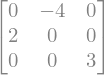

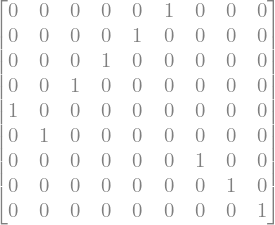

+---+---+---+
|   | 4 |   |
+---+---+---+
| 2 |   |   |
+---+---+---+
|   |   | 3 |
+---+---+---+


In [10]:
mm = MM([-4,2,3], pm.Permutation([1,0,2])) #; print(type(mm), mm['diagonal'], mm['permutation'].act(0))
aprm = mm.associate_PM()
pmtx = sympy.Matrix(aprm.matrix())

display(mm.matrix, pmtx)
mm.show_in_grid()

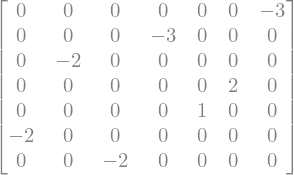

In [21]:
mm = MM([-3,-3,-2,2,1,-2,-2],pm.Permutation([6,3,1,5,4,0,2])) #[7,2,1,4,8,3,6,5,0]))
display(mm.matrix, len(cycle_decomp(mm.associate_PM())))
#, sympy.Matrix(mm.associate_PM()))

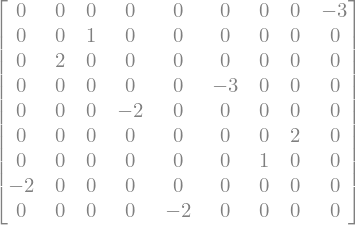

In [22]:
mm = MM([-3,1,2,-3,-2,2,1,-2,-2],pm.Permutation([8,2,1,5,3,7,6,0,4])) #[7,2,1,4,8,3,6,5,0]))
display(mm.matrix, len(cycle_decomp(mm.associate_PM())))
#, sympy.Matrix(mm.associate_PM()))

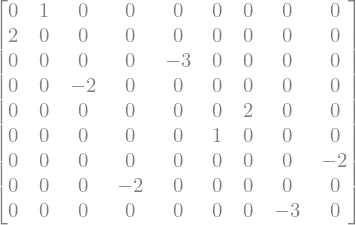

In [23]:
mm = MM([1,2,-3,-2,2,1,-2,-2,-3],pm.Permutation([1,0,4,2,6,5,8,3,7])) #[7,2,1,4,8,3,6,5,0]))
display(mm.matrix, len(cycle_decomp(mm.associate_PM())))
#, sympy.Matrix(mm.associate_PM()))

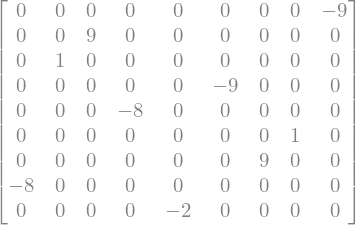

In [45]:
a,b,c = random.randint(1,10),random.randint(1,10), random.randint(1,10)
c, r = 1,1

mm = MM([(-1)*a,b,c,(-1)*a,(-1)*(a-r),c,b,(-1)*(a-r),(-2)*r],pm.Permutation([8,2,1,5,3,7,6,0,4])) #[7,2,1,4,8,3,6,5,0]))
display(mm.matrix, len(cycle_decomp(mm.associate_PM())), 2*(b+int(np.gcd(a,r))))

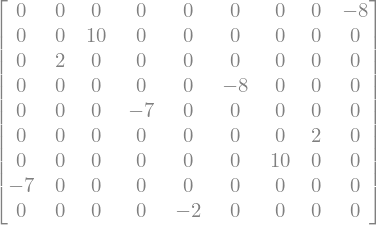

In [51]:
a,b,c = random.randint(1,10),random.randint(1,10), random.randint(1,10)
c, r = 2,1

mm = MM([(-1)*a,b,c,(-1)*a,(-1)*(a-r),c,b,(-1)*(a-r),(-2)*r],pm.Permutation([8,2,1,5,3,7,6,0,4])) #[7,2,1,4,8,3,6,5,0]))
display(mm.matrix, int(len(cycle_decomp(mm.associate_PM()))/2), b+int(np.gcd(a,r)))

## Correctness checking function

### Experiments

### scratch

In [16]:
a,b,c = random.randint(1,10),random.randint(1,10), random.randint(1,10)
r = c + random.randint(1,5)

Z = b%(r-c)
Zi = (r-c)-Z

mm1 = MM([Zi,Z,c,Zi,Z,c,2*(a%r)+r], Perm([6,5,4,3,2,1,0]))
mm2 = MM([Zi,Z,c,a%r], Perm([1,2,3,0]))
mm3 = MM([Zi,Z,c,a%r], Perm([2,3,0,1]))

nums = []
for mm in [mm1, mm2, mm3]: 
    mm.show_in_grid()
    nums.append(len(cycle_decomp(mm.associate_PM())))
print(nums)

+---+---+---+---+---+---+---+
|   |   |   |   |   |   | 2 |
+---+---+---+---+---+---+---+
|   |   |   |   |   |   |   |
+---+---+---+---+---+---+---+
|   |   |   |   | 4 |   |   |
+---+---+---+---+---+---+---+
|   |   |   | 2 |   |   |   |
+---+---+---+---+---+---+---+
|   |   |   |   |   |   |   |
+---+---+---+---+---+---+---+
|   | 4 |   |   |   |   |   |
+---+---+---+---+---+---+---+
| 10 |   |   |   |   |   |   |
+---+---+---+---+---+---+---+
+---+---+---+---+
|   | 2 |   |   |
+---+---+---+---+
|   |   |   |   |
+---+---+---+---+
|   |   |   | 4 |
+---+---+---+---+
| 2 |   |   |   |
+---+---+---+---+
+---+---+---+---+
|   |   | 2 |   |
+---+---+---+---+
|   |   |   |   |
+---+---+---+---+
| 4 |   |   |   |
+---+---+---+---+
|   | 2 |   |   |
+---+---+---+---+
[4, 2, 2]


In [15]:
a,b,c = random.randint(1,10),random.randint(1,10), random.randint(1,10)
r = c + random.randint(1,5)
# a,b,c,r = 9,4,8,3

b1=b%(c-r)
c1=(c-r)-b1

Z = b1%(r-c)
Zi = (r-c)-Z

mm1 = MM([Zi,Z,c,Zi,Z,c,2*(a%r)], Perm([3,2,1,6,5,4,0]))
mm2 = MM([r,b,c,r,b,c,2*(a%r)], Perm([3,2,1,6,5,4,0]))
mm3 = MM([c1,b1,c,c1,b1,c,2*(a%r)], Perm([3,2,1,6,5,4,0]))
mm4 = MM([Zi,Z,c,Zi,Z,c,2*(a%r)], Perm([3,2,1,6,5,4,0]))
mms = [mm1, mm2, mm3, mm4]

print([len(cycle_decomp(mm.associate_PM())) for mm in mms], 2*np.gcd(a,r))
[mm.show_in_grid() for mm in mms]

[2, 4, 4, 2] 2
+---+---+---+---+---+---+---+
|   |   |   | 1 |   |   |   |
+---+---+---+---+---+---+---+
|   |   | 2 |   |   |   |   |
+---+---+---+---+---+---+---+
|   | 8 |   |   |   |   |   |
+---+---+---+---+---+---+---+
|   |   |   |   |   |   | 1 |
+---+---+---+---+---+---+---+
|   |   |   |   |   | 2 |   |
+---+---+---+---+---+---+---+
|   |   |   |   | 8 |   |   |
+---+---+---+---+---+---+---+
| 16 |   |   |   |   |   |   |
+---+---+---+---+---+---+---+
+---+---+---+---+---+---+---+
|   |   |   | 11 |   |   |   |
+---+---+---+---+---+---+---+
|   |   | 8 |   |   |   |   |
+---+---+---+---+---+---+---+
|   | 8 |   |   |   |   |   |
+---+---+---+---+---+---+---+
|   |   |   |   |   |   | 11 |
+---+---+---+---+---+---+---+
|   |   |   |   |   | 8 |   |
+---+---+---+---+---+---+---+
|   |   |   |   | 8 |   |   |
+---+---+---+---+---+---+---+
| 16 |   |   |   |   |   |   |
+---+---+---+---+---+---+---+
+---+---+---+---+---+---+---+
|   |   |   | 2 |   |   |   |
+---+---+---+---+---+

[None, None, None, None]

In [17]:
a, r = random.randint(1,10), random.randint(1,10) #1, 1 #
a = a%r
A = 2*a+1
R = (r-1)%A

print("(a,r,A,R)=({},{},{},{})".format(a,r,A,R))

mm1 = MM([r-1, 1, r-1, 1, 2*a], pm.Permutation([2,1,4,3,0]))
# mm2 = MM([1, r-1, 1, R, A-R],pm.Permutation([4,3,2,1,0]))
mm2 = MM([R, 1, R, 1, 2*a],pm.Permutation([2,1,4,3,0]))
mm3 = MM([R, 1, R, 1, 2*a-R-1],pm.Permutation([4,3,2,1,0]))
mms = [mm1, mm2, mm3]

# [mm.show_in_grid() for mm in mms]

print([int(len(pm.cycle_decomp(mm.associate_PM()))/2) for mm in mms], a+1, np.gcd(A,2*r))

(a,r,A,R)=(5,6,11,5)
[1, 1, 1] 6 1


In [ ]:
N = 15
for count in range(100):
    r = random.randint(1,N)
    a, c = random.randint(1,N)%r, random.randint(1,N)%r #1 #

    mm1 = MM([r-c, c, r-c, c, 2*a],pm.Permutation([2,1,4,3,0]))
    # A = (2*a+c)%(2*r)
    # mm2 = MM([r, r-c, c, (2*a+r)%A, A--(2*a+r)%A],pm.Permutation([4,0,3,2,1]))
    # mms = [mm1,mm2]
    # [mm.show_in_grid() for mm in mms]
    # print([int(len(pm.cycle_decomp(mm1.associate_PM()))/2) for mm in mms], np.gcd(2*a+c,r))
    num = int(len(pm.cycle_decomp(mm1.associate_PM()))/2)
    if not num == np.gcd(2*a+c,r):
        print((a,c,r), [num,np.gcd(2*a+c,r)])

In [ ]:
N = 20
a, b, c, d = random.randint(1,N), random.randint(1,N), random.randint(1,N), random.randint(1,N)
print(a,b,c,d)

mm1 = MM([a,d,b,b,c,c,d],pm.Permutation([2,5,4,0,6,3,1]))
mm2 = MM([a+c+d, a+2*d, 2*b, b+c],pm.Permutation([2,0,3,1]))
A, B = (a+2*d)%(a+c+d), (2*b)%(b+c)
Ai, Bi = (a+c+d)-A, (b+c)-B
mm3 = MM([Ai, A, B, Bi],pm.Permutation([3,2,1,0]))
mms = [mm1, mm2, mm3]

[mm.show_in_grid() for mm in mms]
print([len(pm.cycle_decomp(mm.associate_PM())) for mm in mms])

In [112]:
N = 20
a, b = random.randint(1,N), random.randint(1,N)
s = a+b
C, D = 0, 0
while np.gcd(C,D) != 1:
    C, D = random.randint(1,N), random.randint(1,N)
c,d = C*s, D*s
print(a,b,c,d)

mm = MM([a,b,c,d],pm.Permutation([3,2,1,0]))

mm.show_in_grid()
print(len(pm.cycle_decomp(mm.associate_PM())))

10 14 384 456
+---+---+---+---+
|   |   |   | 10 |
+---+---+---+---+
|   |   | 14 |   |
+---+---+---+---+
|   | 384 |   |   |
+---+---+---+---+
| 456 |   |   |   |
+---+---+---+---+
2


In [53]:
N = 20

a,b,c,d = 0,0,0,0
while d == 0 or a-d == c:
    a, b, c, d = random.randint(1,N), random.randint(1,N), random.randint(1,N), random.randint(1,N)
    d = d%a
D = d%(a-d)

print(a,b,c,d)
mm1 = MM([a, b, c, d],pm.Permutation([3,2,1,0]))
while a-d < c:
    delta = c-(a-d)
    b = b%delta
    c = delta-b
print(a,b,c,d)
mm2 = MM([a, b, c, d],pm.Permutation([3,2,1,0]))
while a-d > c:
    delta = a-d-c
    b = b%delta
    a = delta-b
print(a,b,c,D)
mm3 = MM([a, b, c, d],pm.Permutation([3,2,1,0]))
# print(a,b,c,D)
# mm3 = MM([a, b, c, D],pm.Permutation([3,2,1,0]))

mms = [mm1, mm2, mm3]

[mm.show_in_grid() for mm in mms]
print([len(pm.cycle_decomp(mm.associate_PM())) for mm in mms])

5 2 2 2
5 2 2 2
1 0 2 2
+---+---+---+---+
|   |   |   | 5 |
+---+---+---+---+
|   |   | 2 |   |
+---+---+---+---+
|   | 2 |   |   |
+---+---+---+---+
| 2 |   |   |   |
+---+---+---+---+
+---+---+---+---+
|   |   |   | 5 |
+---+---+---+---+
|   |   | 2 |   |
+---+---+---+---+
|   | 2 |   |   |
+---+---+---+---+
| 2 |   |   |   |
+---+---+---+---+
+---+---+---+---+
|   |   |   | 1 |
+---+---+---+---+
|   |   |   |   |
+---+---+---+---+
|   | 2 |   |   |
+---+---+---+---+
| 2 |   |   |   |
+---+---+---+---+
[1, 1, 1]


### Nando

In [56]:
def correctness_checking(code, restriction=''):
    a,b,c,r = code[0], code[1], code[2], code[3]
    sdata, rdata, case, memo = None, None, None, ''

#-- Transforming MMs --
    if a >= r:
        case = "a>=r"
        s_diag, s_perm_img = [-a,b,c,-a,-(a-r),c,b,-(a-r),-2*r], [8,2,1,5,3,7,6,0,4]
        #---
        A = a%r
        X, Xi = b, c
        Xseq = [X]
        while Xi > r:
            X = X%(Xi-r)
            Xi = (Xi-r)-X
            Xseq.append(X)
        case += ", ...Xseq={}...".format(Xseq)
        if r == Xi:
            case += ", Xi=r"
            if restriction in case:
                diag, perm_img = [2*r,2*A,2*X], [1,0,2]
                memo = "(A,r)+X=({},{})+{}={}+{}".format(A, r, X, np.gcd(A, r),X)
            else: case = None
        else: #r > Xi:
            case += ", Xi<r"
            Z = X%(r-Xi)
            Zi = (r-Xi)-Z
            if restriction in case:
                diag, perm_img = [Zi,Z,Xi,Zi,Z,Xi,2*A], [3,2,1,6,5,4,0]
                # diag, perm_img = [Zi,Z,Xi,Zi,Z,Xi,(2*A+r)%(2*r)], [6,5,4,3,2,1,0]
            else: case = None
    elif r <= a+c:
        case = "a<r<=a+c"
        s_diag, s_perm_img = [-a,b,r-a,a+c-r,-a,a+c-r,b,-2*a,r-a], [8,1,3,0,4,7,5,2,6]
        #---
        B = b%a
        Bi = a-B
        if False: #r == a+c:
            case += ", r=a+c"
            if restriction in case:
                diag, perm_img = [r, Bi, B, B, Bi, r], [2,1,0,5,4,3]
                memo = "(a,r-B)=({},{})={}".format(a, r-B, np.gcd(a,r-B))
            else: case = None
        elif r <= a+c:
            case += ", r<=a+c"
            X, Xi = b, c
            Xseq = [X]
            while Xi > r:
                X = X%(Xi-r)
                Xi = (Xi-r)-X
                Xseq.append(X)
            case += ", ...Xseq={}...".format(Xseq)
            if r == Xi:
                case += ", Xi=r"
                R = r%(2*a)
                Ri = 2*a-R
                if restriction in case:
                    diag, perm_img = [-R,-Ri,-Ri,-R,2*X], [2,3,0,1,4]
                    # diag, perm_img = [r,-2*a,-2*a,r,2*X], [1,3,0,2,4]
                    # memo = "(R,Ri)=({},{})={}".format(R,Ri,np.gcd(R,Ri))
                else: case = None
            else: #r > Xi
                case += ", Xi<r"
                Z = X%(r-Xi)
                Zi = (r-Xi)-Z
                if restriction in case:
                    # diag, perm_img = [Zi,Z,Xi,-2*a,-2*a,Xi,Z,Zi], [3,2,1,7,0,6,5,4]
                  c  diag, perm_img = [Zi,Z,Xi,Zi,Z,Xi,2*a], [3,2,1,6,5,4,0]
                else: case = None
        else: case = None
    elif a+c < r < a+b+c:
        case = "a+c<r<a+b+c"
        ###=== CONSTRUCTING NOW! ===###        
        case = None
    else: case = None
    #----    
    if case is not None: 
        starting_mm = MM(s_diag, pm.Permutation(s_perm_img))
        sdata = {'mm': starting_mm, '#orbits': len(pm.cycle_decomp(starting_mm.associate_PM())), 'memo': ''}
        #---
        resulting_mm = MM(diag, pm.Permutation(perm_img))
        rdata = {'mm': resulting_mm, '#orbits': len(pm.cycle_decomp(resulting_mm.associate_PM())), 'memo': memo}
#----    
    return [sdata, rdata], case

SyntaxError: invalid syntax (3528190006.py, line 68)

In [57]:
def correctness_checking(code, restriction=''):
#-- Starting MM --
    a,b,c,r = code[0], code[1], code[2], code[3]
    starting_mm = MM([-a,b,c,-a,-(a-r),c,b,-(a-r),-2*r], pm.Permutation([8,2,1,5,3,7,6,0,4]))
    snum  = len(pm.cycle_decomp(starting_mm.associate_PM()))
    sdata = {'mm': starting_mm, '#orbits': snum, 'memo': ''}

#-- Resulting MM --
    flag = True
    resulting_mm, rnum, memo = None, None, ''
    if a-r>=0:
        case = "a>=r"
        if r-c == 0:
            case += ", r=c"
            if restriction in case:
                resulting_mm = MM([-r,-a,-(a-r),r,a-r,-2*r,2*b], pm.Permutation([4,2,0,3,5,1,6]))
                rnum = len(pm.cycle_decomp(resulting_mm.associate_PM())) + 2*b
                memo = ", b={}".format(b)
            else: case = "(x)"
        elif r-c > 0:
            case += ", r>c"
            X, Y = b%(r-c), (a-r)%(2*r)
            Xi, Yi = (r-c)-X, (2*r)-Y
            if restriction in case:
                resulting_mm = MM([Xi,X,c,Xi,X,c,2*Y], pm.Permutation([3,2,1,6,5,4,0]))
                rnum = len(pm.cycle_decomp(resulting_mm.associate_PM()))
            else: case = "(x)"
            # if Xi == Y:
            #     case += ", Xi=Y"
            #     resulting_mm = MM([X,c,Xi,X,c,Xi], pm.Permutation([2,1,0,5,4,3]))
            #     rnum = 2*np.gcd(X+c, r-X) #len(pm.cycle_decomp(resulting_mm.associate_PM()))
            #     memo = ", (X+c, r-X)=({},{})={}".format(X+c, r-X, np.gcd(X+c, r-X))
            # elif Xi > Y:
            #     case += ", Xi>Y"
            #     Z = Xi-Y
            #     # resulting_mm = MM([-Z,-X,-c,-Z,Y,-X,-c,-Y,-Yi], pm.Permutation([5,7,8,2,0,3,4,6,1]))
            #     # resulting_mm = MM([-Z,X,c,Z,Y,-X,-c,-Y,-r], pm.Permutation([7,2,1,4,0,5,6,8,3]))
            #     # resulting_mm = MM([Z,X,c,Z,Y,X,c,Y], pm.Permutation([4,2,1,7,0,6,5,3]))
            #     resulting_mm = MM([Xi,X,c,Xi,X,c,2*Y], pm.Permutation([3,2,1,6,5,4,0]))
            #     rnum = len(pm.cycle_decomp(resulting_mm.associate_PM()))
            # else:
            #     case += ", Xi<Y"
            #     # resulting_mm = MM([-Xi,-X,-c,-Xi,-X,-c,Y,-Y,-Yi], pm.Permutation([6,7,8,3,4,5,0,1,2]))
            #     resulting_mm = MM([Xi,X,c,Xi,X,c,2*Y], pm.Permutation([3,2,1,6,5,4,0]))
            #     rnum = len(pm.cycle_decomp(resulting_mm.associate_PM()))
        else: # r-c < 0
            case += ", r<c"
            X, Y = b%(c-r), (a-r)%(2*r)
            Xi, Yi = (c-r)-X, (2*r)-Y
            # if r-Yi == 0:
            #     case += ", r=Yi"
            #     if restriction in case:
            #         resulting_mm = MM([Xi,X,r,r,X,Xi], pm.Permutation([2,1,0,5,4,3]))
            #         rnum = len(pm.cycle_decomp(resulting_mm.associate_PM()))
            #     else: case = "(x)"
            # else:
                # case += ", r!=Yi"
            if r-Xi == 0:
                case += ", r=Xi"
                if restriction in case:
                    resulting_mm = MM([-Y,-Yi,-2*r,Y,2*X], pm.Permutation([2,3,0,1,4]))
                    rnum = len(pm.cycle_decomp(resulting_mm.associate_PM()))
                    memo = ", (Y,r)+X=({},{})+{}={}+{}".format(Y, r, X, np.gcd(Y, r),X)
                else: case = "(x)"
            if r-Xi > 0:
                case += ", r>Xi"
                Z = X%abs(r-Xi)
                Zi = abs(r-Xi)-Z
                if restriction in case:
                    # resulting_mm = MM([2*Y,Xi,X,r,r,X,Xi], pm.Permutation([6,2,1,0,5,4,3]))
                    # resulting_mm = MM([Xi,X,-Y,-Yi,-r,X,Xi,-r,Y], pm.Permutation([2,1,7,8,3,5,4,0,6]))
                    # resulting_mm = MM([Xi,X,-Y,-(Yi-r),r,X,Xi,-r,Y], pm.Permutation([2,1,6,8,7,4,3,0,5]))
                    # resulting_mm = MM([Xi,X,-r,r,X,Xi,-r,2*Y], pm.Permutation([2,1,7,6,4,3,0,5]))
                    resulting_mm = MM([Zi,Z,Xi,Zi,Z,Xi,2*Y], pm.Permutation([3,2,1,6,5,4,0]))
                    rnum = len(pm.cycle_decomp(resulting_mm.associate_PM()))
                else: case = "(x)"
            else: case = "(x)"
    else: case = "(x)"
    rdata = {'mm': resulting_mm, '#orbits': rnum, 'memo': memo}
#----    
    return [sdata, rdata], case